# Band power plots, comparing good models and bad models


- combining +1 and -1 stim

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.io
import os
import importlib
import sys
from collections import defaultdict

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
from bootstrap_method import *
import spect_utils as su


### get some params for the first few plots

In [2]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_types = ['good_models','bad_models']
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

# freqbands_list = ['theta','alpha','beta','gamma1','gamma2']
band_ranges = su.get_band_ranges()

In [3]:
# load a model to get trial times

for models_type in models_types:
    # load list of models
    models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
    model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    print(f'Total: {n_models} {models_type} models')

    for n_model, model_fname in enumerate(model_list):
        
        print(f'Loading model {n_model+1}/{n_models}...')
        model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
        
        break
    break

Total: 41 good_models models
Loading model 1/41...


In [4]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***

times_rate = {
    'T': ipsc_data['T'][0][0],
    'stim_on': ipsc_data['stim_on'][0][0],
    'stim_dur': ipsc_data['stim_dur'][0][0],
    'delay': ipsc_data['delay'][0][0],
    'fs': 200,
}

# get trial times in real time (seconds)
times_real = {
    'stim1_on': times_rate['stim_on']/times_rate['fs'],
    'stim1_off': (times_rate['stim_on'] + times_rate['stim_dur'])/times_rate['fs'],
    'stim2_on': (times_rate['stim_on'] + times_rate['stim_dur'] + times_rate['delay'])/times_rate['fs'],
    'stim2_off': (times_rate['stim_on'] + 2*times_rate['stim_dur'] + times_rate['delay'])/times_rate['fs'],
}

# load spectral time data
t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))
times_fft = {
    'stim1_on': su.get_fft_time(times_real['stim1_on'], t),
    'stim1_off': su.get_fft_time(times_real['stim1_off'], t),
    'stim2_on': su.get_fft_time(times_real['stim2_on'], t),
    'stim2_off': su.get_fft_time(times_real['stim2_off'], t),
}

# adjust for x-axis labels
t_skip = 15

In [5]:
normalize_ipscs = 1 # usually will be 1
lesion_connections = 0 # if not lesioning put 0, else 'ii' etc. usually 0 here bc we're comparing good vs bad models
longer_delay = '' # '' if standard delay (150), longer can be 200, 250, 400

models_types = ['good_models','bad_models']
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

## first let's plot good models only (essentially cosyne fig 2A)

In [6]:
models_type = models_types[0] # good models only

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
n_models = len(model_list)
print(f'Total: {n_models} {models_type} models')

Total: 41 good_models models


### recalculate all s, normalizing, and then store band powers

here, we're not longer splitting by stim1 label

In [10]:
from collections import defaultdict

stim1_pathlabel = ['_pos','_neg']
neur_pathlabel = ['_exc','_inh']
# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

good_bands_all = defaultdict(lambda: defaultdict(list))

for n_model, model_fname in enumerate(model_list):

    print(f'Loading model {n_model+1}/{n_models}...')
    model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
    
    # load to get trial times
    ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
    ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
    T = ipsc_data['T'][0][0]
    stim_on = ipsc_data['stim_on'][0][0]
    stim_dur = ipsc_data['stim_dur'][0][0]
    delay = ipsc_data['delay'][0][0]
    fs_rate = 200
    fs_spk = 20000
    del ipsc_data

    # for n_stim1, stim1 in enumerate(stim1_pathlabel):
    for n_neur, neur in enumerate(neur_pathlabel):
        # get s for stim1_pos and stim1_neg
        s = []
        for n_stim1, stim1 in enumerate(stim1_pathlabel):
            this_s = np.load(os.path.join(model_dir, f's{stim1}{neur}{norm_name[0]}{lesion_name[0]}{delay_name}.npy'))
            s.append(this_s)
        
        # mean of stim1_pos and stim1_neg
        s = np.mean(s, axis=0)

        f = np.load(os.path.join(model_dir, 'f.npy'))
        t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

        # normalized averaged spect by baseline
        bl_period_fft = [int(times_fft['stim1_on']*1/2), times_fft['stim1_on']] # second half of fixation period
        s_bl_mean = np.nanmean(s[:,bl_period_fft[0]:bl_period_fft[1]], axis=1)
        s = s / s_bl_mean[:,np.newaxis]

        bandpower, _ = su.calc_band_power(10*np.log(s), f, band='all')

        for key in bandpower:
            key_name = f'{neur_label[n_neur]}'
            good_bands_all[key_name][key].append(bandpower[key])

# convert to numpy arrays
for key in good_bands_all:
    for subkey in good_bands_all[key]:
        good_bands_all[key][subkey] = np.array(good_bands_all[key][subkey])

Loading model 1/41...
Loading model 2/41...
Loading model 3/41...
Loading model 4/41...
Loading model 5/41...
Loading model 6/41...
Loading model 7/41...
Loading model 8/41...
Loading model 9/41...
Loading model 10/41...
Loading model 11/41...
Loading model 12/41...
Loading model 13/41...
Loading model 14/41...
Loading model 15/41...
Loading model 16/41...
Loading model 17/41...
Loading model 18/41...
Loading model 19/41...
Loading model 20/41...
Loading model 21/41...
Loading model 22/41...
Loading model 23/41...
Loading model 24/41...
Loading model 25/41...
Loading model 26/41...
Loading model 27/41...
Loading model 28/41...
Loading model 29/41...
Loading model 30/41...
Loading model 31/41...
Loading model 32/41...
Loading model 33/41...
Loading model 34/41...
Loading model 35/41...
Loading model 36/41...
Loading model 37/41...
Loading model 38/41...
Loading model 39/41...
Loading model 40/41...
Loading model 41/41...


In [11]:
for key in good_bands_all:
    for subkey in good_bands_all[key]:
        print(f'{key} {subkey}: {good_bands_all[key][subkey].shape}')

exc theta: (41, 241)
exc alpha: (41, 241)
exc beta: (41, 241)
exc gamma1: (41, 241)
exc gamma2: (41, 241)
inh theta: (41, 241)
inh alpha: (41, 241)
inh beta: (41, 241)
inh gamma1: (41, 241)
inh gamma2: (41, 241)


In [12]:
good_bands_all.keys()

dict_keys(['exc', 'inh'])

Comparing exc and inh...


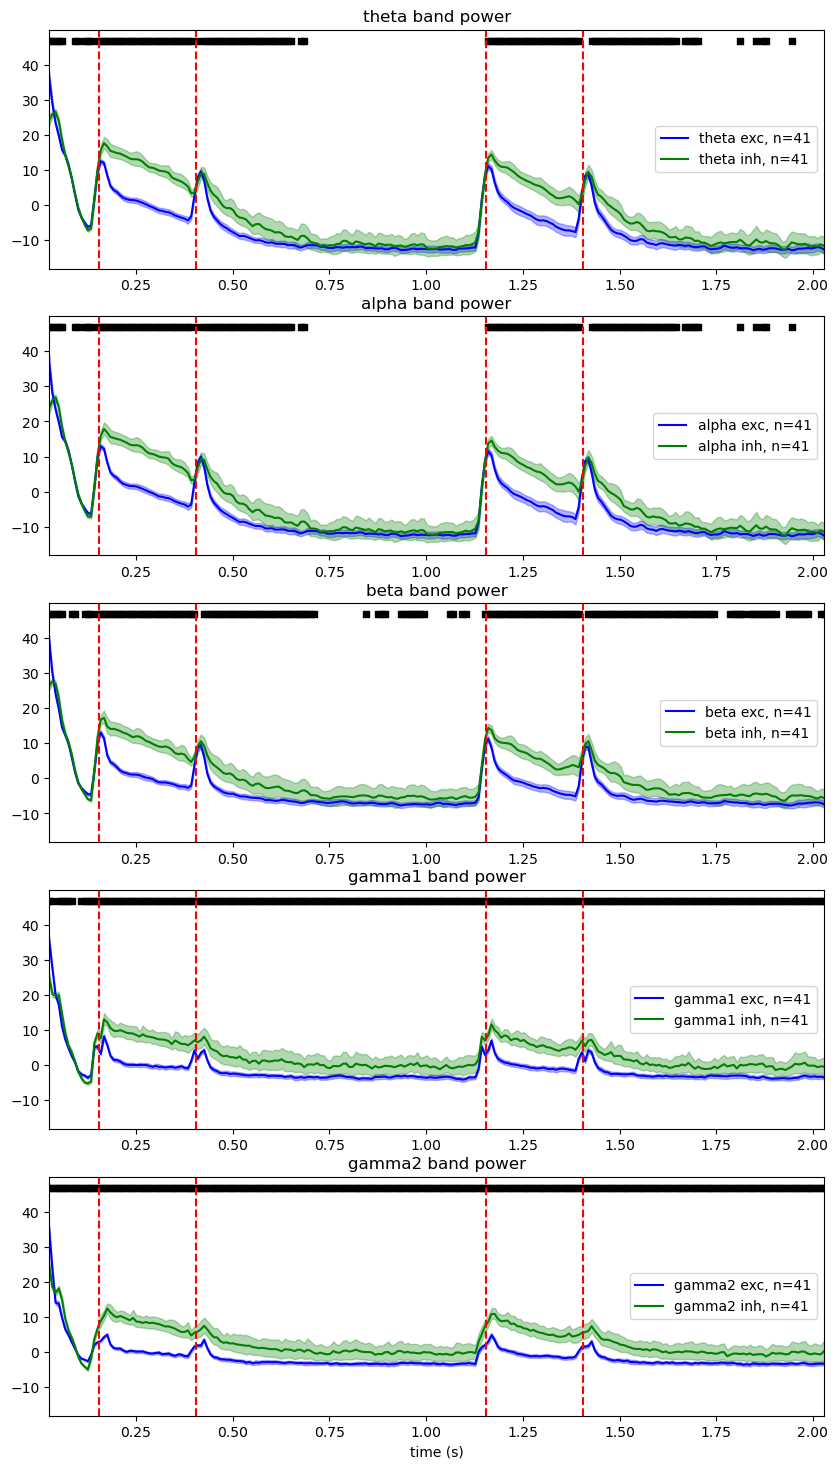

In [13]:
# compare exc and inh for combined stim


stim1_label = ['+1','-1']
neur_label = ['exc','inh']

# bl_period_times = np.array([(times['stimulus']+6)*1/4, (times['stimulus']+6)*1]) - 6
# bl_period_fft = cs.get_fft_time(bl_period_times, t)

importlib.reload(su)

print(f'Comparing exc and inh...')

key1 = f'{neur_label[0]}'
key2 = f'{neur_label[1]}'

su.plot_band_power_bootstrap(good_bands_all[key1], good_bands_all[key2], 
                                t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                                adjust_bands2=False, baseline_idx = bl_period_fft,
                                type1_label=f'{key1}, n={len(good_bands_all[key1]["theta"])}', 
                                type2_label=f'{key2}, n={len(good_bands_all[key2]["theta"])}', 
                                p_sig=0.05, title = [],
                                event_times = times_real, 
                                t_skip=20,
                                band_range = [], time_range = [np.nan, np.nan], 
                            )

## Now let's look at bad models only (for visualization; not a figure)

In [14]:
models_type = models_types[1] # bad models only

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
n_models = len(model_list)
print(f'Total: {n_models} {models_type} models')

Total: 26 bad_models models


### recalculate all s, normalizing, and then store band powers

In [15]:
from collections import defaultdict

stim1_pathlabel = ['_pos','_neg']
neur_pathlabel = ['_exc','_inh']
# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

bad_bands_all = defaultdict(lambda: defaultdict(list))

for n_model, model_fname in enumerate(model_list):

    print(f'Loading model {n_model+1}/{n_models}...')
    model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
    
    # load to get trial times
    ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
    ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
    T = ipsc_data['T'][0][0]
    stim_on = ipsc_data['stim_on'][0][0]
    stim_dur = ipsc_data['stim_dur'][0][0]
    delay = ipsc_data['delay'][0][0]
    fs_rate = 200
    fs_spk = 20000
    del ipsc_data

    # for n_stim1, stim1 in enumerate(stim1_pathlabel):
    for n_neur, neur in enumerate(neur_pathlabel):
        # get s for stim1_pos and stim1_neg
        s = []
        for n_stim1, stim1 in enumerate(stim1_pathlabel):
            this_s = np.load(os.path.join(model_dir, f's{stim1}{neur}{norm_name[0]}{lesion_name[0]}{delay_name}.npy'))
            s.append(this_s)
        
        # mean of stim1_pos and stim1_neg
        s = np.mean(s, axis=0)

        f = np.load(os.path.join(model_dir, 'f.npy'))
        t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

        # normalized averaged spect by baseline
        bl_period_fft = [int(times_fft['stim1_on']*1/2), times_fft['stim1_on']] # second half of fixation period
        s_bl_mean = np.nanmean(s[:,bl_period_fft[0]:bl_period_fft[1]], axis=1)
        s = s / s_bl_mean[:,np.newaxis]

        bandpower, _ = su.calc_band_power(10*np.log(s), f, band='all')

        for key in bandpower:
            key_name = f'{neur_label[n_neur]}'
            bad_bands_all[key_name][key].append(bandpower[key])

# convert to numpy arrays
for key in bad_bands_all:
    for subkey in bad_bands_all[key]:
        bad_bands_all[key][subkey] = np.array(bad_bands_all[key][subkey])

Loading model 1/26...
Loading model 2/26...
Loading model 3/26...
Loading model 4/26...
Loading model 5/26...
Loading model 6/26...
Loading model 7/26...
Loading model 8/26...
Loading model 9/26...
Loading model 10/26...
Loading model 11/26...
Loading model 12/26...
Loading model 13/26...
Loading model 14/26...
Loading model 15/26...
Loading model 16/26...
Loading model 17/26...
Loading model 18/26...
Loading model 19/26...
Loading model 20/26...
Loading model 21/26...
Loading model 22/26...
Loading model 23/26...
Loading model 24/26...
Loading model 25/26...
Loading model 26/26...


In [16]:
for key in bad_bands_all:
    for subkey in bad_bands_all[key]:
        print(f'{key} {subkey}: {bad_bands_all[key][subkey].shape}')

exc theta: (26, 241)
exc alpha: (26, 241)
exc beta: (26, 241)
exc gamma1: (26, 241)
exc gamma2: (26, 241)
inh theta: (26, 241)
inh alpha: (26, 241)
inh beta: (26, 241)
inh gamma1: (26, 241)
inh gamma2: (26, 241)


In [17]:
bad_bands_all.keys()

dict_keys(['exc', 'inh'])

Comparing exc and inh...


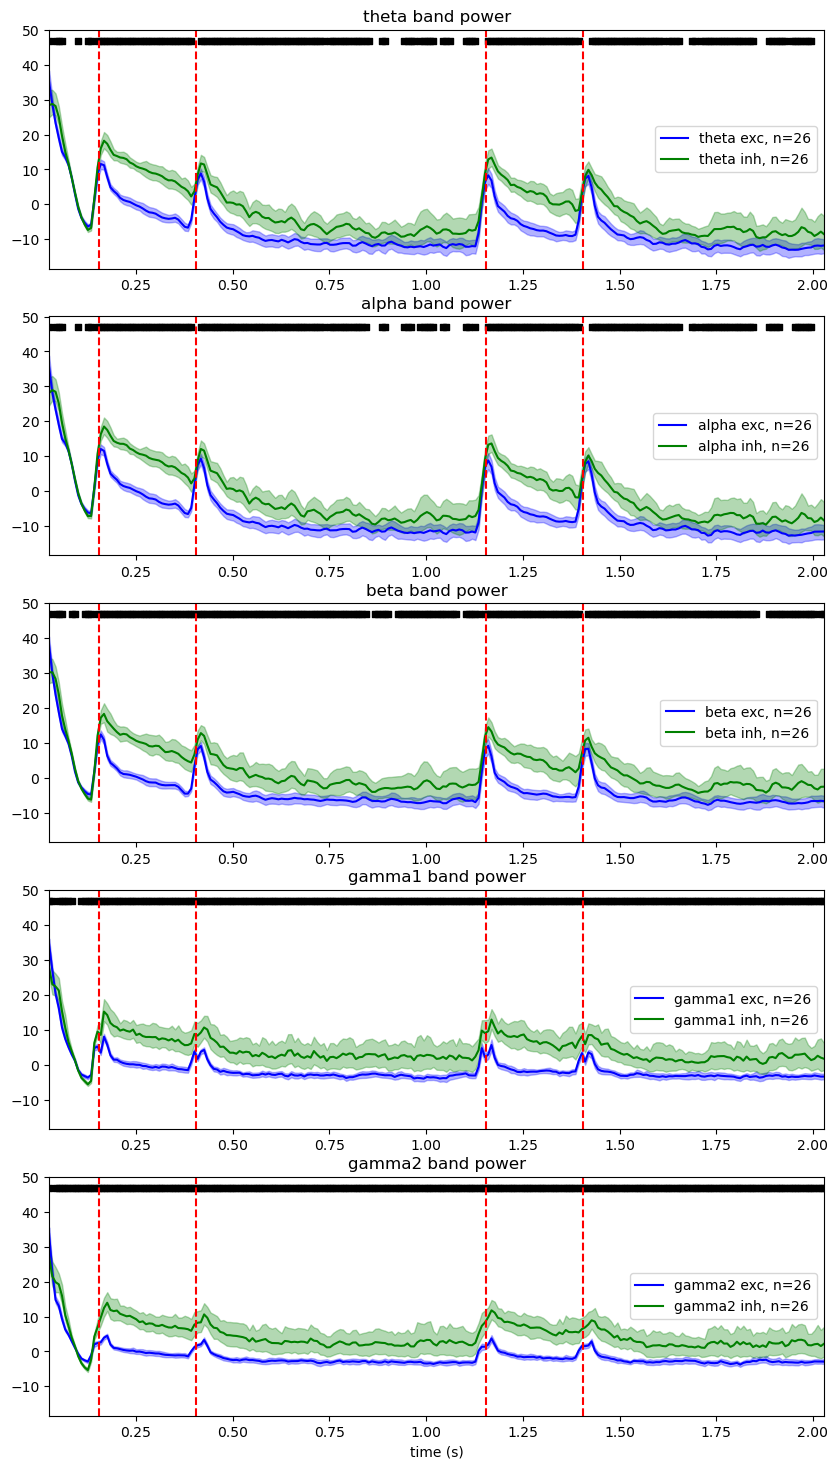

In [19]:
# compare exc and inh for each stim


# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

# bl_period_times = np.array([(times['stimulus']+6)*1/4, (times['stimulus']+6)*1]) - 6
# bl_period_fft = cs.get_fft_time(bl_period_times, t)

importlib.reload(su)

# for n_stim1, stim1 in enumerate(stim1_label):
print(f'Comparing exc and inh...')

key1 = f'{neur_label[0]}'
key2 = f'{neur_label[1]}'

su.plot_band_power_bootstrap(bad_bands_all[key1], bad_bands_all[key2], 
                                t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                                adjust_bands2=False, baseline_idx = bl_period_fft,
                                type1_label=f'{key1}, n={len(bad_bands_all[key1]["theta"])}', 
                                type2_label=f'{key2}, n={len(bad_bands_all[key2]["theta"])}', 
                                p_sig=0.05, title = [],
                                event_times = times_real, 
                                t_skip=20,
                                band_range = [], time_range = [np.nan, np.nan], 
                            )

## Now let's compare good and bad models (essentially fig 2b)


In [20]:
good_colors = ['#007a7a','#004747']
bad_colors = ['#7a007a', '#470047']

Comparing exc...


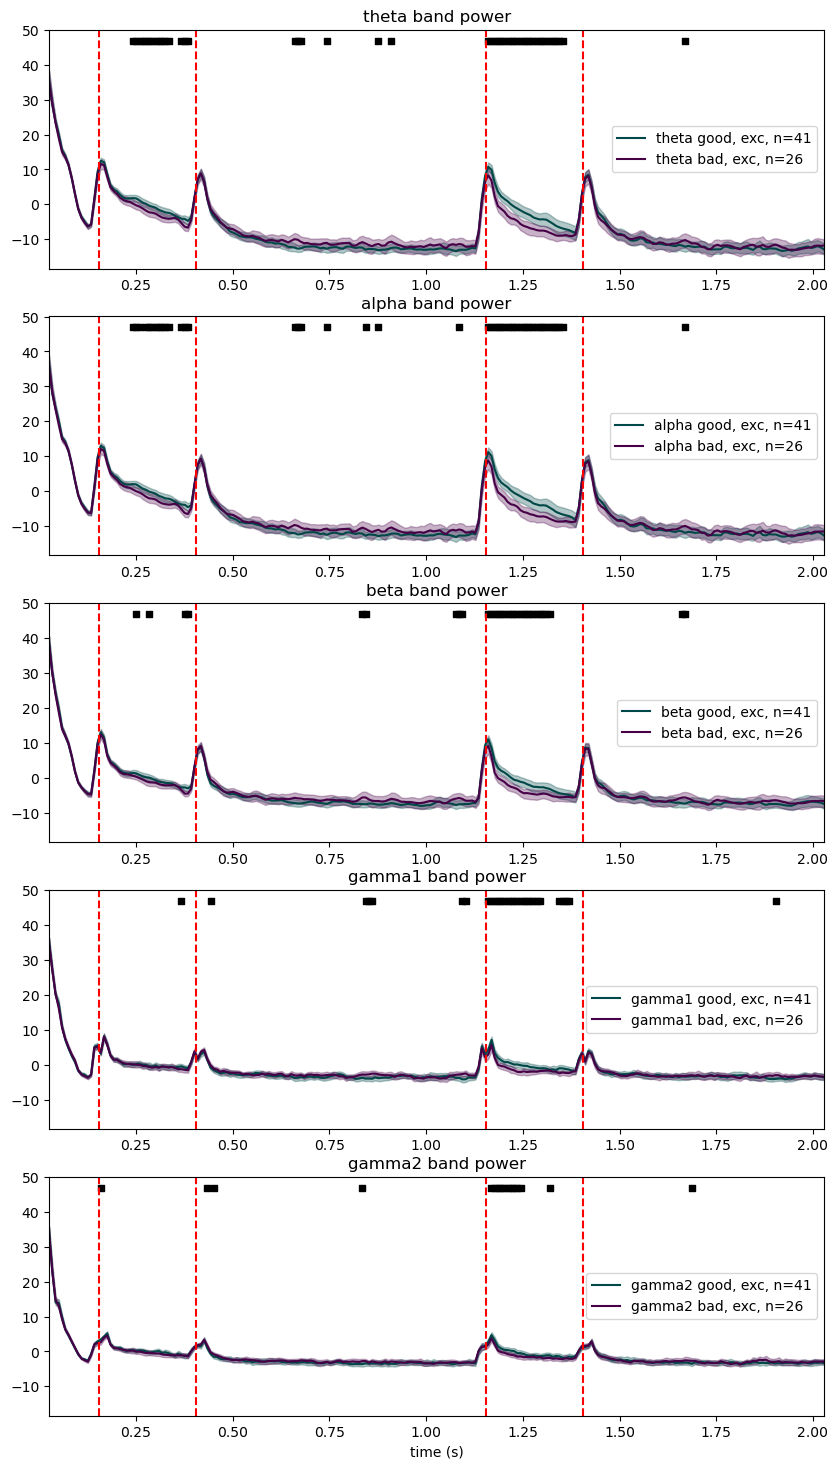

Comparing inh...


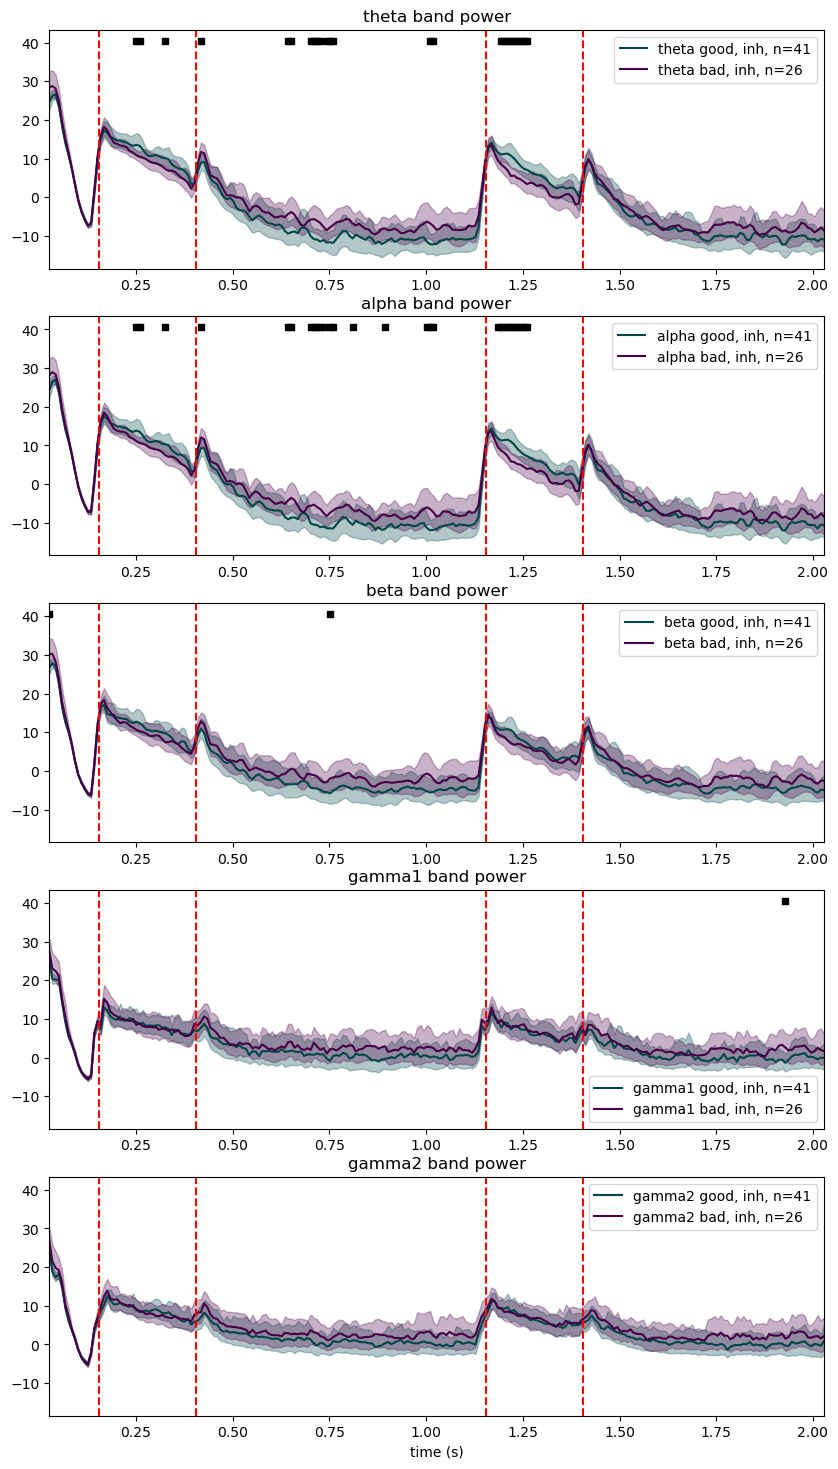

In [22]:
# compare exc and inh for each stim


# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

# bl_period_times = np.array([(times['stimulus']+6)*1/4, (times['stimulus']+6)*1]) - 6
# bl_period_fft = cs.get_fft_time(bl_period_times, t)

importlib.reload(su)

# for n_stim1, stim1 in enumerate(stim1_label):
for n_neur, neur in enumerate(neur_label):
    print(f'Comparing {neur_label[n_neur]}...')

    key = f'{neur}'

    su.plot_band_power_bootstrap(good_bands_all[key], bad_bands_all[key], 
                                    t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                                    adjust_bands2=False, baseline_idx = bl_period_fft,
                                    type1_label=f'good, {key}, n={len(good_bands_all[key]["theta"])}', 
                                    type2_label=f'bad, {key}, n={len(bad_bands_all[key]["theta"])}', 
                                    p_sig=0.05, title = [], #f'comparing good v bad {key}',
                                    event_times = times_real, 
                                    t_skip=20, c= [good_colors[n_stim1], bad_colors[n_stim1]],
                                    band_range = [], time_range = [np.nan, np.nan], 
                                )

### violin plots..

In [23]:
# get delay means

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located

stim1_pathlabel = ['_pos','_neg']
neur_pathlabel = ['_exc','_inh']
# stim1_label = ['+1','-1']
neur_label = ['exc','inh']


for n_models_type, models_type in enumerate(models_types):

    results_dir = f'{models_dir}{models_type}/' # dir where results are saved

    model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
    model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
    model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
    n_models = len(model_list)
    print(f'Total: {n_models} {models_type} models')

    delaymeans_all = defaultdict(lambda: defaultdict(list))

    for n_model, model_fname in enumerate(model_list):

        print(f'Loading model {n_model+1}/{n_models}...')
        model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model

        # for n_stim1, stim1 in enumerate(stim1_pathlabel):
        for n_neur, neur in enumerate(neur_pathlabel):
            # print(f'Loading {stim1_label[n_stim1]} {neur_label[n_neur]}...')
            # s = np.load(os.path.join(model_dir, f's{stim1}{neur}{norm_name[0]}{lesion_name[0]}{delay_name}.npy'))
            s = []
            for n_stim1, stim1 in enumerate(stim1_pathlabel):
                this_s = np.load(os.path.join(model_dir, f's{stim1}{neur}{norm_name[0]}{lesion_name[0]}{delay_name}.npy'))
                s.append(this_s)
        
            # mean of stim1_pos and stim1_neg
            s = np.mean(s, axis=0)
            
            f = np.load(os.path.join(model_dir, 'f.npy'))
            t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

            delay_start = times_fft['stim1_off']
            delay_end = times_fft['stim2_on']

            # normalized averaged spect by baseline
            bl_period_fft = [int(times_fft['stim1_on']*1/2), times_fft['stim1_on']] # second half of fixation period
            s_bl_mean = np.nanmean(s[:,bl_period_fft[0]:bl_period_fft[1]], axis=1)
            s = s / s_bl_mean[:,np.newaxis]

            bandpower, _ = su.calc_band_power(10*np.log(s), f, band='all')

            for key in bandpower:
                key_name = f'{neur_label[n_neur]}'
                delaymeans_all[key_name][key].append(np.mean(bandpower[key][delay_start:delay_end]))

    # convert to numpy arrays
    for key in delaymeans_all:
        for subkey in delaymeans_all[key]:
            delaymeans_all[key][subkey] = np.array(delaymeans_all[key][subkey])

    if n_models_type == 0:
        good_delaymeans_all = delaymeans_all
    else:
        bad_delaymeans_all = delaymeans_all
    del delaymeans_all

Total: 41 good_models models
Loading model 1/41...
Loading model 2/41...
Loading model 3/41...
Loading model 4/41...
Loading model 5/41...
Loading model 6/41...
Loading model 7/41...
Loading model 8/41...
Loading model 9/41...
Loading model 10/41...
Loading model 11/41...
Loading model 12/41...
Loading model 13/41...
Loading model 14/41...
Loading model 15/41...
Loading model 16/41...
Loading model 17/41...
Loading model 18/41...
Loading model 19/41...
Loading model 20/41...
Loading model 21/41...
Loading model 22/41...
Loading model 23/41...
Loading model 24/41...
Loading model 25/41...
Loading model 26/41...
Loading model 27/41...
Loading model 28/41...
Loading model 29/41...
Loading model 30/41...
Loading model 31/41...
Loading model 32/41...
Loading model 33/41...
Loading model 34/41...
Loading model 35/41...
Loading model 36/41...
Loading model 37/41...
Loading model 38/41...
Loading model 39/41...
Loading model 40/41...
Loading model 41/41...
Total: 26 bad_models models
Loading m

In [24]:
# print array sizes

for key in good_delaymeans_all:
    for subkey in good_delaymeans_all[key]:
        print(f'{key} {subkey}: {good_delaymeans_all[key][subkey].shape}')

exc theta: (41,)
exc alpha: (41,)
exc beta: (41,)
exc gamma1: (41,)
exc gamma2: (41,)
inh theta: (41,)
inh alpha: (41,)
inh beta: (41,)
inh gamma1: (41,)
inh gamma2: (41,)


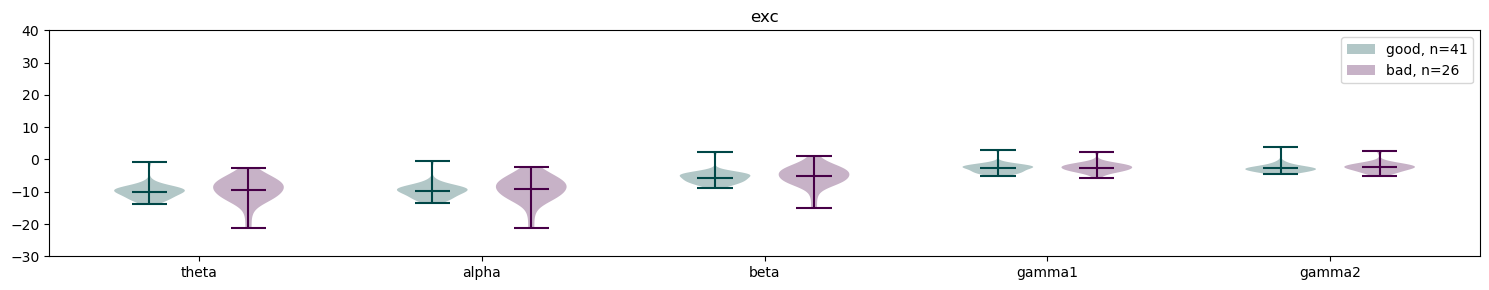

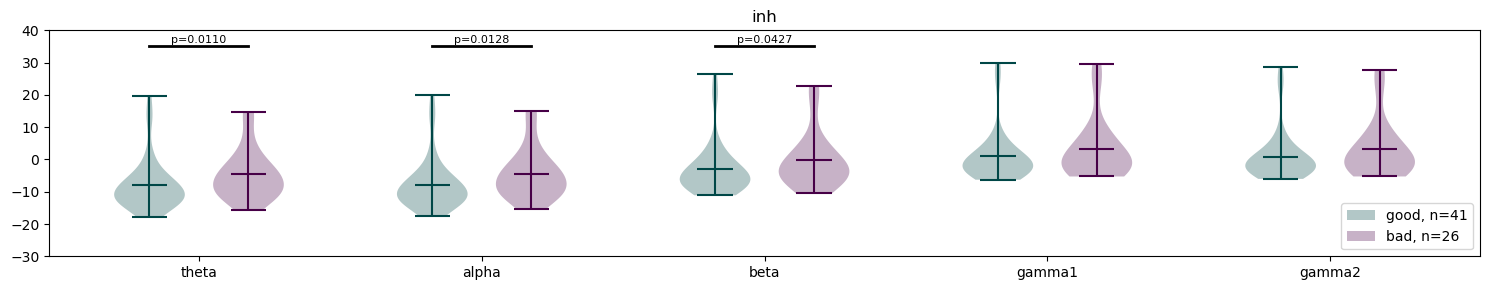

In [29]:
# make violin plots

x_closer = 0.15


for n_neur, neur in enumerate(neur_label):

    fig, ax = plt.subplots(1,1, figsize=(15,3))
    x_vals = np.arange(10)

    key = f'{neur}'

    for i, band_key in enumerate(good_delaymeans_all[key].keys()):
        # plot across the x-axis
        this_x = x_vals[i*2:i*2+2]
        good_vals = good_delaymeans_all[key][band_key].squeeze().astype(float)
        bad_vals = bad_delaymeans_all[key][band_key].squeeze().astype(float)
        # dif = good_vals - bad_vals
        # _, p = scipy.stats.wilcoxon(dif, zero_method='wilcox', alternative='greater', nan_policy='omit') # compute wilcoxon signed rank test
        # compute mann whitney u test
        _, p = scipy.stats.mannwhitneyu(good_vals, bad_vals) # 2-sided
        # _, p = scipy.stats.mannwhitneyu(good_vals, bad_vals, alternative='less') # 1-sided
        parts1 = ax.violinplot(good_vals, positions=[this_x[0]+x_closer], showmeans=True, showextrema=True)
        parts2 = ax.violinplot(bad_vals, positions=[this_x[1]-x_closer], showmeans=True, showextrema=True)
        parts = [parts1, parts2]
        these_colors = [good_colors[n_stim1], bad_colors[n_stim1]]
        for j, part in enumerate(parts):
            part['bodies'][0].set_facecolor(these_colors[j])
            part['cmins'].set_edgecolor(these_colors[j])
            part['cmaxes'].set_edgecolor(these_colors[j])
            part['cmeans'].set_edgecolor(these_colors[j])
            part['cbars'].set_edgecolor(these_colors[j])
        
        # for j in range(len(good_vals)):
        #     ax.plot([this_x[0], this_x[1]], [good_vals[j], bad_vals[j]], 'k-', alpha=0.1)
        
        # line for significant pairs
        if p < 0.05:
            y_pos = 35
            ax.plot([this_x[0]+x_closer, this_x[1]-x_closer], [y_pos, y_pos], 'k-', lw=2)
            # ax.text(np.mean([this_x[0], this_x[1]]), y_pos, '*', fontsize=12, ha='center')
            # print p-value above the star
            ax.text(np.mean([this_x[0], this_x[1]]), y_pos+1, f'p={p:.4f}', fontsize=8, ha='center')
        
    # ax.set_ylim([-15, 25])
    ax.set_ylim([-30,40])
    x = np.array([np.mean(x_vals[i:i+2]) for i in range(0, len(x_vals), 2)])
    ax.set_xticks(x, good_delaymeans_all[key].keys())
    ax.legend([parts1['bodies'][0], parts2['bodies'][0]], [f'good, n={len(good_vals)}', f'bad, n={len(bad_vals)}'])
    ax.set_title(key)
    plt.tight_layout()
    plt.show()

## Let's do good vs lesion

### first get lesion recalculation

In [30]:
models_type = models_types[0] # good models only

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
n_models = len(model_list)
print(f'Total: {n_models} {models_type} models')

Total: 41 good_models models


#### recalculate all s, normalizing, and then store band powers

In [42]:
from collections import defaultdict

stim1_pathlabel = ['_pos','_neg']
neur_pathlabel = ['_exc','_inh']
# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

lesion_name = ['', '_lesionii']

lesion_bands_all = defaultdict(lambda: defaultdict(list))

for n_model, model_fname in enumerate(model_list):

    print(f'Loading model {n_model+1}/{n_models}...')
    model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
    
    # load to get trial times
    ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[1]}{longer_delay}.mat'
    ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
    T = ipsc_data['T'][0][0]
    stim_on = ipsc_data['stim_on'][0][0]
    stim_dur = ipsc_data['stim_dur'][0][0]
    delay = ipsc_data['delay'][0][0]
    fs_rate = 200
    fs_spk = 20000
    del ipsc_data

    # for n_stim1, stim1 in enumerate(stim1_pathlabel):
    for n_neur, neur in enumerate(neur_pathlabel):
        # print(f'Loading {stim1_label[n_stim1]} {neur_label[n_neur]}...')
        s = []
        for n_stim1, stim1 in enumerate(stim1_pathlabel):
            this_s = np.load(os.path.join(model_dir, f's{stim1}{neur}{norm_name[0]}{lesion_name[1]}{delay_name}.npy'))
            s.append(this_s)
    
        # mean of stim1_pos and stim1_neg
        s = np.mean(s, axis=0)
        
        
        f = np.load(os.path.join(model_dir, 'f.npy'))
        t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

        # normalized averaged spect by baseline
        bl_period_fft = [int(times_fft['stim1_on']*1/2), times_fft['stim1_on']] # second half of fixation period
        s_bl_mean = np.nanmean(s[:,bl_period_fft[0]:bl_period_fft[1]], axis=1)
        s = s / s_bl_mean[:,np.newaxis]

        bandpower, _ = su.calc_band_power(10*np.log(s), f, band='all')

        for key in bandpower:
            key_name = f'{neur_label[n_neur]}'
            lesion_bands_all[key_name][key].append(bandpower[key])

# convert to numpy arrays
for key in lesion_bands_all:
    for subkey in lesion_bands_all[key]:
        lesion_bands_all[key][subkey] = np.array(lesion_bands_all[key][subkey])

Loading model 1/41...
Loading model 2/41...
Loading model 3/41...
Loading model 4/41...
Loading model 5/41...
Loading model 6/41...
Loading model 7/41...
Loading model 8/41...
Loading model 9/41...
Loading model 10/41...
Loading model 11/41...
Loading model 12/41...
Loading model 13/41...
Loading model 14/41...
Loading model 15/41...
Loading model 16/41...
Loading model 17/41...
Loading model 18/41...
Loading model 19/41...
Loading model 20/41...
Loading model 21/41...
Loading model 22/41...
Loading model 23/41...
Loading model 24/41...
Loading model 25/41...
Loading model 26/41...
Loading model 27/41...
Loading model 28/41...
Loading model 29/41...
Loading model 30/41...
Loading model 31/41...
Loading model 32/41...
Loading model 33/41...
Loading model 34/41...
Loading model 35/41...
Loading model 36/41...
Loading model 37/41...
Loading model 38/41...
Loading model 39/41...
Loading model 40/41...
Loading model 41/41...


In [43]:
for key in lesion_bands_all:
    for subkey in lesion_bands_all[key]:
        print(f'{key} {subkey}: {lesion_bands_all[key][subkey].shape}')

exc theta: (41, 241)
exc alpha: (41, 241)
exc beta: (41, 241)
exc gamma1: (41, 241)
exc gamma2: (41, 241)
inh theta: (41, 241)
inh alpha: (41, 241)
inh beta: (41, 241)
inh gamma1: (41, 241)
inh gamma2: (41, 241)


In [44]:
lesion_bands_all.keys()

dict_keys(['exc', 'inh'])

Comparing exc and inh...


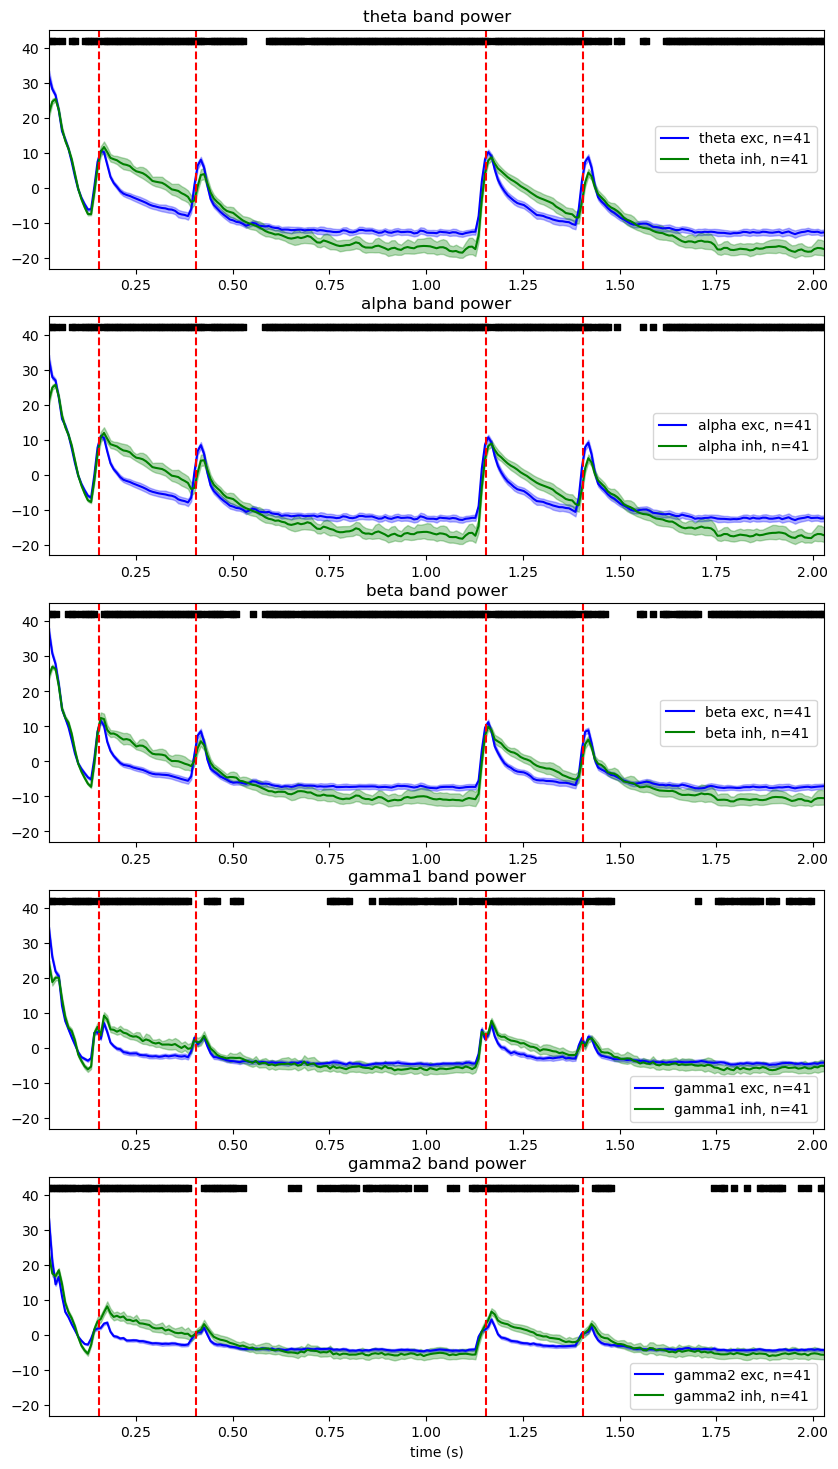

In [45]:
# compare exc and inh for each stim


# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

# bl_period_times = np.array([(times['stimulus']+6)*1/4, (times['stimulus']+6)*1]) - 6
# bl_period_fft = cs.get_fft_time(bl_period_times, t)

importlib.reload(su)

# for n_stim1, stim1 in enumerate(stim1_label):
print(f'Comparing exc and inh...')

key1 = f'{neur_label[0]}'
key2 = f'{neur_label[1]}'

su.plot_band_power_bootstrap(lesion_bands_all[key1], lesion_bands_all[key2], 
                                t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                                adjust_bands2=False, baseline_idx = bl_period_fft,
                                type1_label=f'{key1}, n={len(lesion_bands_all[key1]["theta"])}', 
                                type2_label=f'{key2}, n={len(lesion_bands_all[key2]["theta"])}', 
                                p_sig=0.05, title = [],
                                event_times = times_real, 
                                t_skip=20,
                                band_range = [], time_range = [np.nan, np.nan], 
                            )

### now compare good vs lesioned

In [37]:
good_colors = ['#007a7a','#004747']
bad_colors = ['#7a007a', '#470047']
lesion_colors = ['#D76735', '#B12A0C']

Comparing -1 exc...
exc


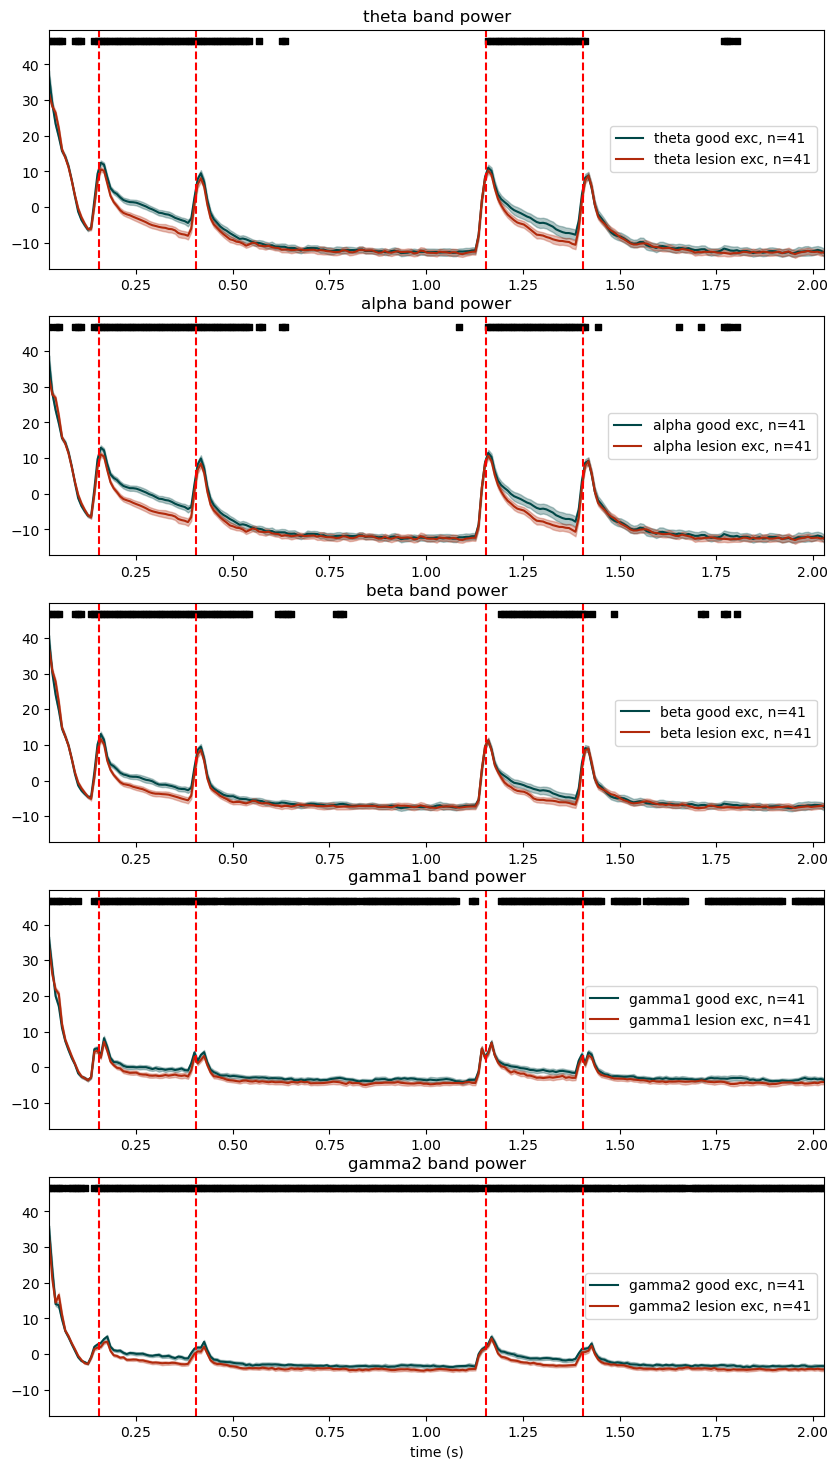

Comparing -1 inh...
inh


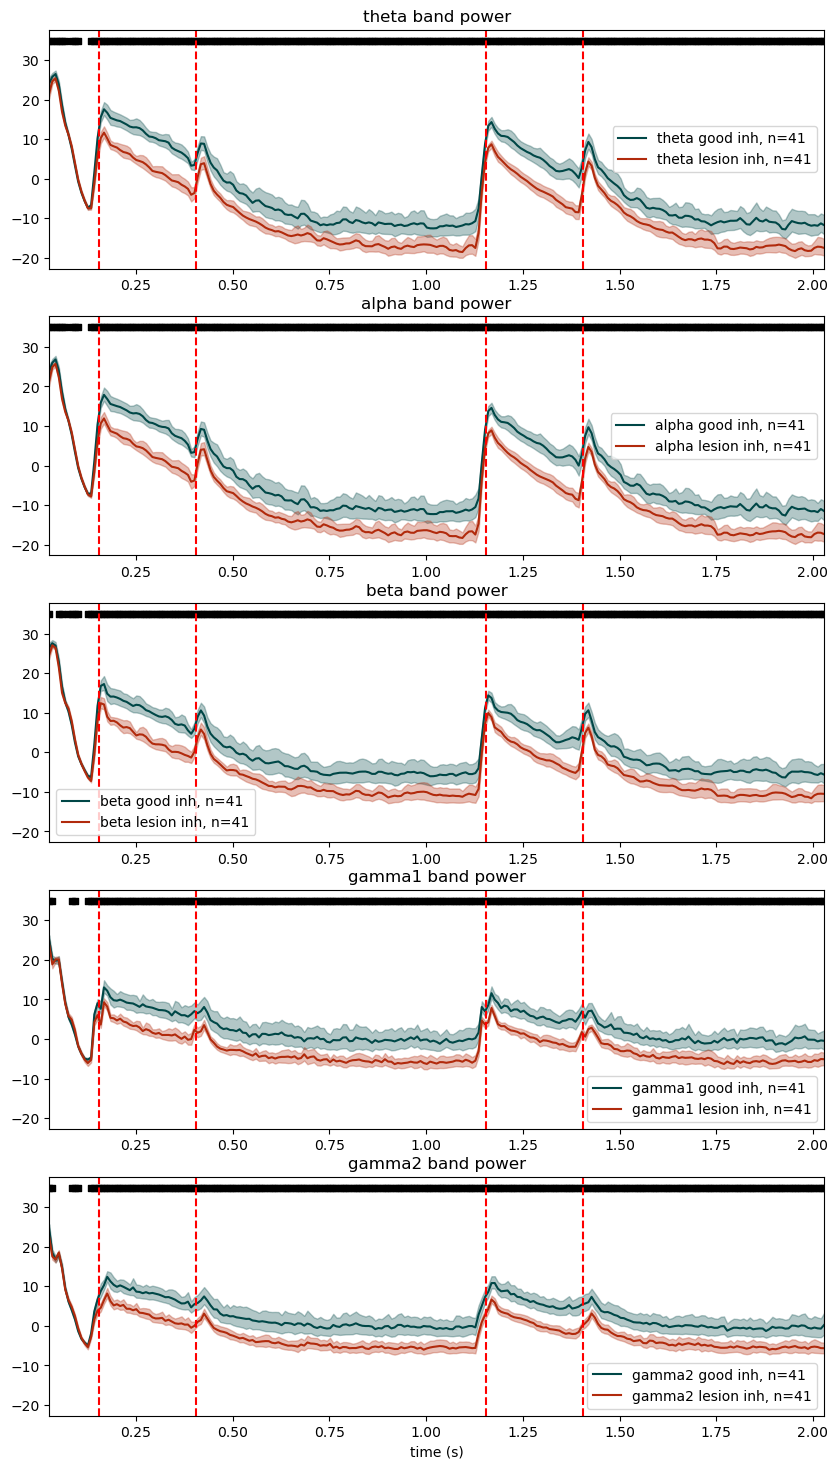

In [ ]:
# compare exc and inh for each stim


# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

# bl_period_times = np.array([(times['stimulus']+6)*1/4, (times['stimulus']+6)*1]) - 6
# bl_period_fft = cs.get_fft_time(bl_period_times, t)

importlib.reload(su)

# for n_stim1, stim1 in enumerate(stim1_label):
for n_neur, neur in enumerate(neur_label):
    print(f'Comparing {neur_label[n_neur]}...')

    key = f'{neur}'
    print(key)

    su.plot_band_power_bootstrap(good_bands_all[key], lesion_bands_all[key], 
                                    t, nboot=1000, CI_int=(2.5, 97.5), random_seed=820,
                                    adjust_bands2=False, baseline_idx = bl_period_fft,
                                    type1_label=f'good {key}, n={len(good_bands_all[key]["theta"])}', 
                                    type2_label=f'lesion {key}, n={len(lesion_bands_all[key]["theta"])}', 
                                    p_sig=0.05, title = [], #f'comparing good v bad {key}',
                                    event_times = times_real, 
                                    t_skip=20, c= [good_colors[n_stim1], lesion_colors[n_stim1]],
                                    band_range = [], time_range = [np.nan, np.nan], 
                                )

#### violin plots

In [47]:
# get delay means for lesion ii

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located

stim1_pathlabel = ['_pos','_neg']
neur_pathlabel = ['_exc','_inh']
# stim1_label = ['+1','-1']
neur_label = ['exc','inh']

lesion_name = ['', '_lesionii']

models_type = models_types[0] # good models only

results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
n_models = len(model_list)
print(f'Total: {n_models} {models_type} models')

delaymeans_all = defaultdict(lambda: defaultdict(list))

for n_model, model_fname in enumerate(model_list):

    print(f'Loading model {n_model+1}/{n_models}...')
    model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model

    # for n_stim1, stim1 in enumerate(stim1_pathlabel):
    for n_neur, neur in enumerate(neur_pathlabel):
        # print(f'Loading {stim1_label[n_stim1]} {neur_label[n_neur]}...')
        # s = np.load(os.path.join(model_dir, f's{stim1}{neur}{norm_name[0]}{lesion_name[1]}{delay_name}.npy'))
        s = []
        for n_stim1, stim1 in enumerate(stim1_pathlabel):
            this_s = np.load(os.path.join(model_dir, f's{stim1}{neur}{norm_name[0]}{lesion_name[1]}{delay_name}.npy'))
            s.append(this_s)
    
        # mean of stim1_pos and stim1_neg
        s = np.mean(s, axis=0)
        
        f = np.load(os.path.join(model_dir, 'f.npy'))
        t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

        delay_start = times_fft['stim1_off']
        delay_end = times_fft['stim2_on']

        # normalized averaged spect by baseline
        bl_period_fft = [int(times_fft['stim1_on']*1/2), times_fft['stim1_on']] # second half of fixation period
        s_bl_mean = np.nanmean(s[:,bl_period_fft[0]:bl_period_fft[1]], axis=1)
        s = s / s_bl_mean[:,np.newaxis]

        bandpower, _ = su.calc_band_power(10*np.log(s), f, band='all')

        for key in bandpower:
            key_name = f'{neur_label[n_neur]}'
            delaymeans_all[key_name][key].append(np.mean(bandpower[key][delay_start:delay_end]))

# convert to numpy arrays
for key in delaymeans_all:
    for subkey in delaymeans_all[key]:
        delaymeans_all[key][subkey] = np.array(delaymeans_all[key][subkey])

lesion_delaymeans_all = delaymeans_all
del delaymeans_all

Total: 41 good_models models
Loading model 1/41...
Loading model 2/41...
Loading model 3/41...
Loading model 4/41...
Loading model 5/41...
Loading model 6/41...
Loading model 7/41...
Loading model 8/41...
Loading model 9/41...
Loading model 10/41...
Loading model 11/41...
Loading model 12/41...
Loading model 13/41...
Loading model 14/41...
Loading model 15/41...
Loading model 16/41...
Loading model 17/41...
Loading model 18/41...
Loading model 19/41...
Loading model 20/41...
Loading model 21/41...
Loading model 22/41...
Loading model 23/41...
Loading model 24/41...
Loading model 25/41...
Loading model 26/41...
Loading model 27/41...
Loading model 28/41...
Loading model 29/41...
Loading model 30/41...
Loading model 31/41...
Loading model 32/41...
Loading model 33/41...
Loading model 34/41...
Loading model 35/41...
Loading model 36/41...
Loading model 37/41...
Loading model 38/41...
Loading model 39/41...
Loading model 40/41...
Loading model 41/41...


In [48]:
# print array sizes

for key in lesion_delaymeans_all:
    for subkey in lesion_delaymeans_all[key]:
        print(f'{key} {subkey}: {lesion_delaymeans_all[key][subkey].shape}')

exc theta: (41,)
exc alpha: (41,)
exc beta: (41,)
exc gamma1: (41,)
exc gamma2: (41,)
inh theta: (41,)
inh alpha: (41,)
inh beta: (41,)
inh gamma1: (41,)
inh gamma2: (41,)


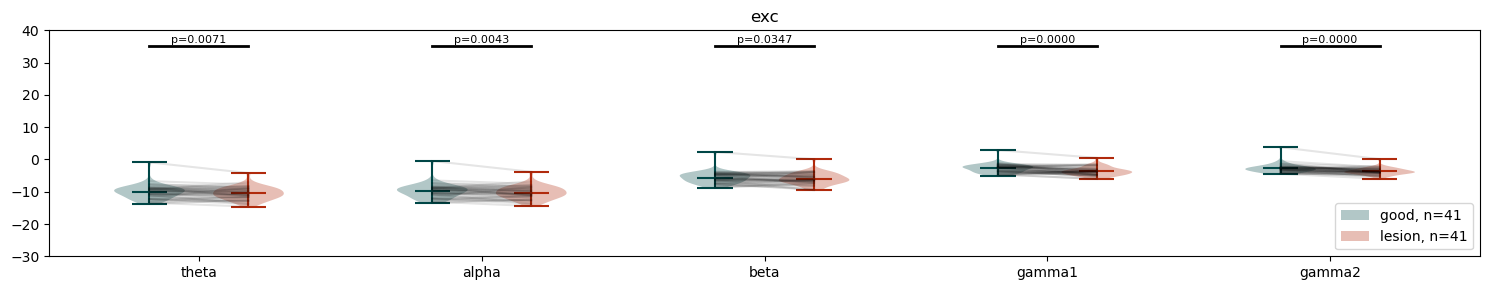

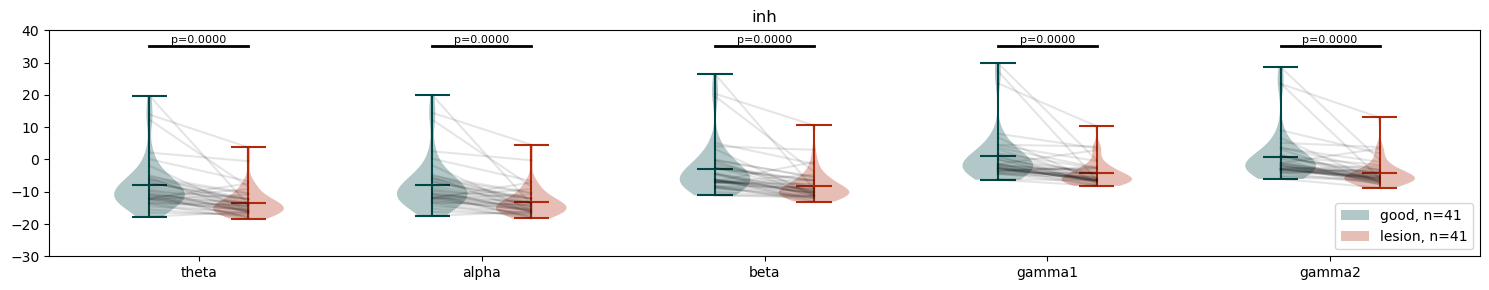

In [49]:
# make violin plots

x_closer = 0.15

# for n_stim1, stim1 in enumerate(stim1_label):
for n_neur, neur in enumerate(neur_label):

    fig, ax = plt.subplots(1,1, figsize=(15,3))
    x_vals = np.arange(10)

    key = f'{neur}'

    for i, band_key in enumerate(good_delaymeans_all[key].keys()):
        # plot across the x-axis
        this_x = x_vals[i*2:i*2+2]
        good_vals = good_delaymeans_all[key][band_key].squeeze().astype(float)
        lesion_vals = lesion_delaymeans_all[key][band_key].squeeze().astype(float)
        dif = good_vals - lesion_vals
        _, p = scipy.stats.wilcoxon(dif, zero_method='wilcox', alternative='greater', nan_policy='omit') # compute wilcoxon signed rank test
        
        
        parts1 = ax.violinplot(good_vals, positions=[this_x[0]+x_closer], showmeans=True, showextrema=True)
        parts2 = ax.violinplot(lesion_vals, positions=[this_x[1]-x_closer], showmeans=True, showextrema=True)
        parts = [parts1, parts2]
        these_colors = [good_colors[n_stim1], lesion_colors[n_stim1]]
        for j, part in enumerate(parts):
            part['bodies'][0].set_facecolor(these_colors[j])
            part['cmins'].set_edgecolor(these_colors[j])
            part['cmaxes'].set_edgecolor(these_colors[j])
            part['cmeans'].set_edgecolor(these_colors[j])
            part['cbars'].set_edgecolor(these_colors[j])
        
        for j in range(len(good_vals)):
            ax.plot([this_x[0]+x_closer, this_x[1]-x_closer], [good_vals[j], lesion_vals[j]], 'k-', alpha=0.1)
        
        # line for significant pairs
        if p < 0.05:
            y_pos = 35
            ax.plot([this_x[0]+x_closer, this_x[1]-x_closer], [y_pos, y_pos], 'k-', lw=2)
            # ax.text(np.mean([this_x[0], this_x[1]]), y_pos, '*', fontsize=12, ha='center')
            # print p-value above the star
            ax.text(np.mean([this_x[0], this_x[1]]), y_pos+1, f'p={p:.4f}', fontsize=8, ha='center')
        
    # ax.set_ylim([-15, 25])
    ax.set_ylim([-30,40])
    x = np.array([np.mean(x_vals[i:i+2]) for i in range(0, len(x_vals), 2)])
    ax.set_xticks(x, good_delaymeans_all[key].keys())
    ax.legend([parts1['bodies'][0], parts2['bodies'][0]], [f'good, n={len(good_vals)}', f'lesion, n={len(lesion_vals)}'])
    ax.set_title(key)
    plt.tight_layout()
    plt.show()

# Old code

## 2A. Exc/Inh differences in good models, high gamma

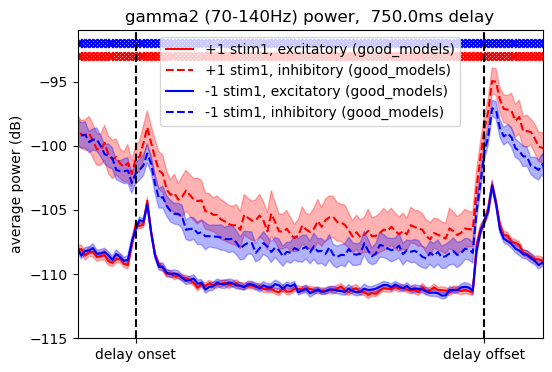

In [10]:
# plot good models separately, for gamma band

models_type = models_types[0] # good models only

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved
all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

# Access the powers by their names
all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
all_powers_pos_inh = all_powers['all_powers_pos_inh']
all_powers_neg_exc = all_powers['all_powers_neg_exc']
all_powers_neg_inh = all_powers['all_powers_neg_inh']
del all_powers

# combine 
all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]

# get band powers from each spectrogram
powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                np.mean(all_powers_pos_inh, axis=0)]
powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                    np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                np.mean(all_powers_neg_inh, axis=0)]
powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                    np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

# Info for plot

band_means = np.zeros((len(freqbands_list),2,2,len(t)))
band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
band_pdiff = np.zeros((len(freqbands_list),2,all_powers[0][0].shape[2]))
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
        elif power == "alpha":
            power_range = [9,12]
        elif power == "beta":
            power_range = [13,30]
        elif power == "gamma1":
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    for k, trial_type in enumerate(['+1', '-1']):
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            if trial_type == '+1':
                band_mean = powers_pos_mean[j][i,:]
                band_sem = powers_pos_sem[j][i,:]
            else:
                band_mean = powers_neg_mean[j][i,:]
                band_sem = powers_neg_sem[j][i,:]
            band_means[i,j,k,:] = band_mean
            band_sems[i,j,k,:] = band_sem

        _, _, _, pdiff = fnc_time_bootstrap_optimized(all_powers[k][0][:,i,:], # same trial type, dif neuron type
                                                    all_powers[k][1][:,i,:], 
                                                    nboot, CI_int, n_jobs=10, random_seed=random_seed)
        # time_vector = np.array(range(0, all_powers[k][0].shape[2]))
        # significant_timepoints = time_vector[pdiff < 0.05]
        band_pdiff[i,k,:] = pdiff

# band_means, band_sems should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
# pdiff is freqband x trial type x timepoints

t_skip = 20

# plot good gamma
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
            continue
        elif power == "alpha":
            power_range = [9,12]
            continue
        elif power == "beta":
            power_range = [13,30]
            continue
        elif power == "gamma1":
            power_range = [30,55]
            continue
        elif power == "gamma2":
            power_range = [70,140]
    plt.figure(figsize=(6,4))
    for k, trial_type in enumerate(['+1', '-1']):
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            band_mean = band_means[i,j,k,:]
            band_sem = band_sems[i,j,k,:]
            plt.plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[0][k], alpha=1, linestyle=['-','--'][j])
            plt.fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[0][k], alpha=0.3)
        time_vector = np.array(range(0, all_powers[k][0].shape[2]))
        significant_timepoints = time_vector[band_pdiff[i,k,:] < 0.05]
        plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)-93+k*1, color=colors[0][k], label='_nolegend_', marker='x')

    plt.axvline(x=stim1_on_idx, color='k', linestyle='--')
    plt.axvline(x=stim1_off_idx, color='k', linestyle='--')
    plt.axvline(x=stim2_on_idx, color='k', linestyle='--')
    plt.axvline(x=stim2_off_idx, color='k', linestyle='--')
    # plt.xlabel('time (s)')
    plt.ylabel('average power (dB)')
    # plt.xticks(range(len(t))[::t_skip],t[::t_skip])
    plt.xticks([stim1_off_idx, stim2_on_idx], ['delay onset', 'delay offset'])
    plt.ylim([-115, -91])
    plt.xlim([half_stim1_idx, half_stim2_idx])
    if len(lesion_name[0]) > 0:
        lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
    else:
        lesion_name_title = ''
    plt.title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power, {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
    plt.legend()
    # plt.savefig(f'{final_results_dir}2A_{power}_diff_exc+inh{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


## 2B. Comparing good vs bad, inhibitory

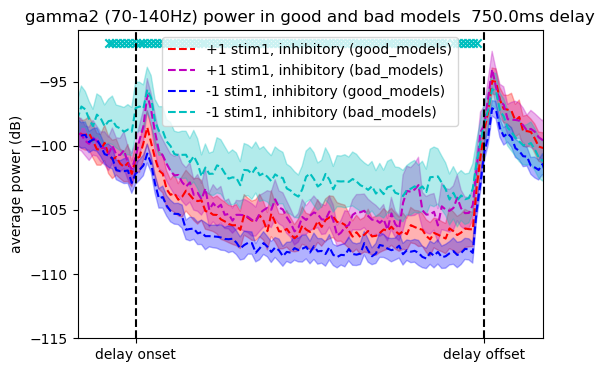

In [16]:
# plot inh neurons btwn good/bad models, for gamma band

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for models_type in models_types:
    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)
    

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    del all_powers_pos_exc, all_powers_pos_inh, all_powers_neg_exc, all_powers_neg_inh

    # Calculations for plotting

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for k, trial_type in enumerate(['+1', '-1']):
            for j, neuron_type in enumerate(['excitatory','inhibitory']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)

t_skip = 20

# plot inh gamma
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            power_range = [4,8]
            continue
        elif power == "alpha":
            power_range = [9,12]
            continue
        elif power == "beta":
            power_range = [13,30]
            continue
        elif power == "gamma1":
            power_range = [30,55]
            continue
        elif power == "gamma2":
            power_range = [70,140]
    
    plt.figure(figsize=(6,4))
    
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        if neuron_type == 'excitatory':
            continue
        for k, trial_type in enumerate(['+1', '-1']):
            for m, models_type in enumerate(models_types):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                plt.plot(band_mean, label=f'{trial_type} stim1, {neuron_type} ({models_type})', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                plt.fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model, same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)-93+k*1, color=colors[m][k], label='_nolegend_', marker='x')

        plt.axvline(x=stim1_on_idx, color='k', linestyle='--')
        plt.axvline(x=stim1_off_idx, color='k', linestyle='--')
        plt.axvline(x=stim2_on_idx, color='k', linestyle='--')
        plt.axvline(x=stim2_off_idx, color='k', linestyle='--')
        # plt.xlabel('time (s)')
        plt.ylabel('average power (dB)')
        # plt.xticks(range(len(t))[::t_skip],t[::t_skip])
        plt.xticks([stim1_off_idx, stim2_on_idx], ['delay onset', 'delay offset'])
        plt.ylim([-115, -91])
        plt.xlim([half_stim1_idx, half_stim2_idx])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        plt.title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power in good and bad models {norm_name[0]}{lesion_name_title} {delay/200*1000}ms delay')
        plt.legend()
    plt.savefig(f'{final_results_dir}2B_{power}_diff_good+bad{norm_name[0]}{lesion_name[0]}{delay_name}.svg', format='svg')


## 2C. Effects of lesioning on model behavioral performance

In [13]:
from scipy import stats

Comparing no lesion vs no lesion, p-value: 1.0
Comparing no lesion vs I - I, p-value: 6.45063427207173e-15
Comparing no lesion vs E - E, p-value: 0.4838098963354255
Comparing no lesion vs E - I, p-value: 1.261838290967975e-06
Comparing no lesion vs I - E, p-value: 7.302494447564684e-08
Comparing I - I vs no lesion, p-value: 6.45063427207173e-15
Comparing I - I vs I - I, p-value: 1.0
Comparing I - I vs E - E, p-value: 6.45063427207173e-15
Comparing I - I vs E - I, p-value: 3.668656319572383e-14
Comparing I - I vs I - E, p-value: 6.45063427207173e-15
Comparing E - E vs no lesion, p-value: 0.4838098963354255
Comparing E - E vs I - I, p-value: 6.45063427207173e-15
Comparing E - E vs E - E, p-value: 1.0
Comparing E - E vs E - I, p-value: 6.862908743551084e-06
Comparing E - E vs I - E, p-value: 1.1490902424596303e-06
Comparing E - I vs no lesion, p-value: 1.261838290967975e-06
Comparing E - I vs I - I, p-value: 3.668656319572383e-14
Comparing E - I vs E - E, p-value: 6.862908743551084e-06
Co

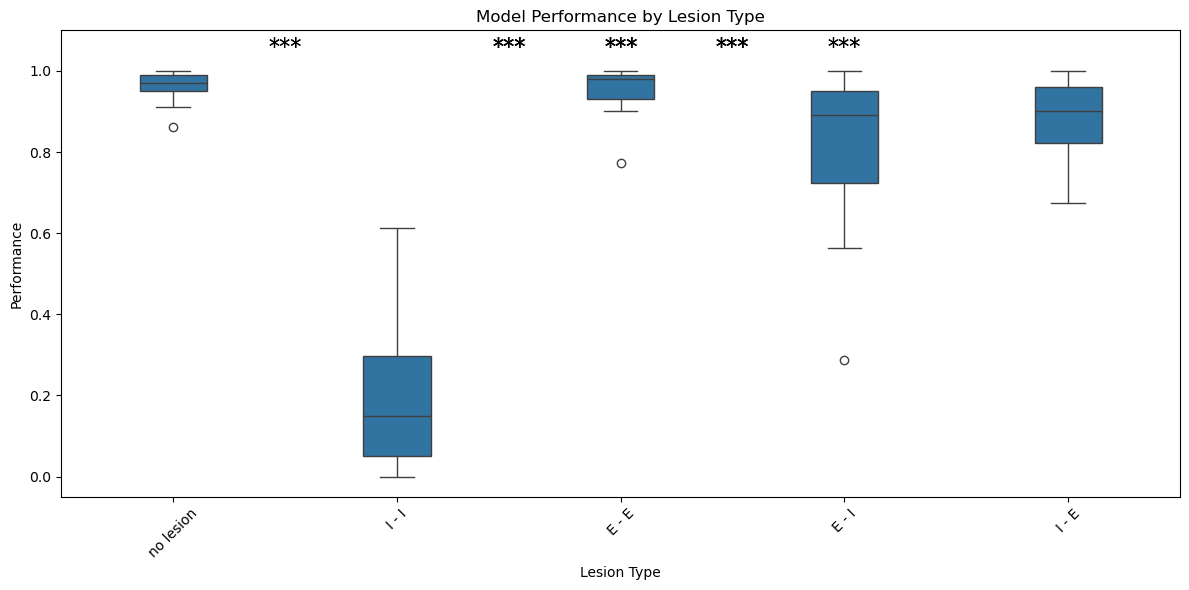

In [35]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import scipy.io
import pandas as pd
from scipy import stats

# Define model types and lesion connections
models_type = 'good_models'
lesion_connections_list = ['no lesion', 'I - I', 'E - E', 'E - I', 'I - E']
models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/'  # Directory where all models are located

# Initialize lists to hold data
all_performance = []
all_model_types = []
all_lesion_connections = []

# Loop through the model types and gather data
model_performance = scipy.io.loadmat(f'{models_dir}{models_type}/{models_type}_performance.mat')['eval_perf_mean']
    
# Assuming model_performance is structured as (n_models, n_lesions)
for lesion_idx in range(model_performance.shape[1]):
    all_performance.extend(model_performance[:, lesion_idx])  # Collect performance scores for the lesion type
    all_lesion_connections.extend([lesion_connections_list[lesion_idx]] * model_performance.shape[0])  # Add lesion type for each score

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'Lesion Connection': all_lesion_connections,
    'Performance': all_performance
})

# Create a grouped boxplot
plt.figure(figsize=(12, 6))
ax = sns.boxplot(x='Lesion Connection', y='Performance', 
                 data=data, width=0.3, dodge=True) 
plt.title('Model Performance by Lesion Type')
plt.xlabel('Lesion Type')
plt.ylabel('Performance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim([-0.05, 1.1])

# Perform the Wilcoxon rank-sum test between model types for each lesion type
for i, connection1 in enumerate(lesion_connections_list):
    for j, connection2 in enumerate(lesion_connections_list):

        # Extract performance for both model types for the current lesion type
        group1 = data[data['Lesion Connection'] == connection1]['Performance']
        group2 = data[data['Lesion Connection'] == connection2]['Performance']
        
        # Perform the rank-sum test only if both groups have data
        if not group1.empty and not group2.empty:
            statistic, p_value = stats.ranksums(group1, group2)
            print(f'Comparing {connection1} vs {connection2}, p-value: {p_value}')

            # Determine significance level for annotation
            if p_value < 0.001:
                significance = '***'
            elif p_value < 0.01:
                significance = '**'
            elif p_value < 0.05:
                significance = '*'
            else:
                significance = ''
            
            # # Get the x position for the current lesion connection
            # x_pos = (lesion_connections_list.index(connection1) + lesion_connections_list.index(connection2))/2
            
            # # Annotate the significance on the plot
            # if significance:
            #     # Adjust y position for the annotation
            #     y_pos = max(data['Performance']) + 0.03  # Adjust this based on data
            #     ax.annotate(significance, 
            #                 xy=(x_pos, y_pos), 
            #                 ha='center', 
            #                 va='bottom',
            #                 fontsize=16) 

plt.savefig(f'{final_results_dir}2C_lesion_performance.eps', format='eps')
plt.show()


## 2D. Effects of I→I lesioning on high gamma power in inhibitory neurons

In [36]:
normalize_ipscs = 1 # usually will be 1
lesion_connections_list = [0, 'ii'] # if not lesioning put 0, else 'ii' etc
longer_delay = '' # '' if standard delay (150), longer can be 200 or 250

models_type = 'good_models'
norm_name = ['' if normalize_ipscs == 1 else '_raw']
lesion_name = ['' if lesion_connections_list[0] == 0 else f'_lesion{lesion_connections_list[0]}'] #temporary
delay_name = ['' if longer_delay == '' else f'_delay{longer_delay}'][0]

freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

In [16]:
# load a model to get trial times

models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
model_list_path = f'{models_dir}{models_type}/{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]
n_models = len(model_list)
print(f'Total: {n_models} {models_type} models')

for n_model, model_fname in enumerate(model_list):
    
    print(f'Loading model {n_model+1}/{n_models}...')
    model_dir = os.path.join(models_dir, model_fname[:model_fname.rfind('.')]) # dir for this model
    
    break

Total: 41 good_models models
Loading model 1/41...


In [17]:
# get necessary trial timing info 

ipsc_savename = f'IPSCs_50travg{norm_name[0]}{lesion_name[0]}{longer_delay}.mat'
ipsc_data = scipy.io.loadmat(os.path.join(model_dir, ipsc_savename)) # load IPSC data ***
T = ipsc_data['T'][0][0]
stim_on = ipsc_data['stim_on'][0][0]
stim_dur = ipsc_data['stim_dur'][0][0]
delay = ipsc_data['delay'][0][0]
fs_rate = 200
fs_spk = 20000
del ipsc_data

# get trial times in real time (seconds)
stim_on_time = stim_on/fs_rate
stim_dur_time = stim_dur/fs_rate
delay_time = delay/fs_rate
stim1_on = stim_on_time
stim1_off = stim_on_time + stim_dur_time
stim2_on = stim_on_time + stim_dur_time + delay_time
stim2_off = stim_on_time + 2*stim_dur_time + delay_time

# load spectral time data
t = np.load(os.path.join(models_dir, f't{delay_name}.npy'))

# plotting info
stim1_on_idx = np.where(t <= stim1_on)[0][-1]
stim1_off_idx = np.where(t <= stim1_off)[0][-1]
stim2_on_idx = np.where(t <= stim2_on)[0][-1]
stim2_off_idx = np.where(t <= stim2_off)[0][-1]


In [18]:
# adjust for x-axis labels
t_skip = 20

In [19]:
# add utils folder to path, and import bootstrap
import sys
sys.path.append('/home/nuttidalab/Documents/spikeRNN/utils/')
from bootstrap_method import *

loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers.npz
loading /home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/good_models/all_powers_lesionii.npz


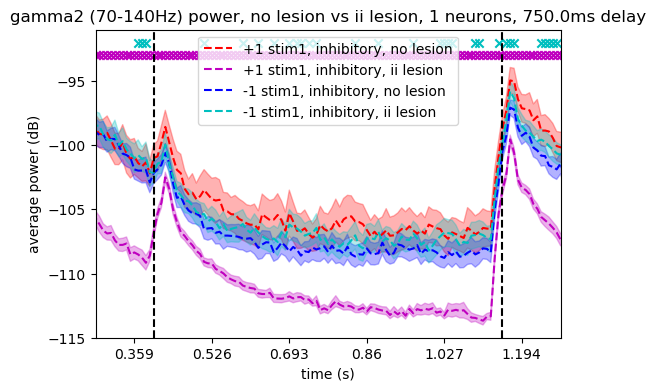

In [ ]:
# plot just gamma2 for inhibitory
freqbands_list = ['theta','alpha','beta','gamma1','gamma2']

# plot lesioning differences for each power band
lesion_connections_list = [0, 'ii'] # if not lesioning put 0, else 'ii' etc

# bootstrapping params
random_seed = 820
nboot = 1000
CI_int = (2.5, 97.5)  # 95% confidence interval

models_bandmeans = []
models_bandsems = []
models_all_powers = []
for lesion_connections in lesion_connections_list:

    lesion_name = ['' if lesion_connections == 0 else f'_lesion{lesion_connections}']

    models_dir = '/home/nuttidalab/Documents/spikeRNN/models/DMS_OSF/' # dir where all models are located
    results_dir = f'{models_dir}{models_type}/' # dir where results are saved
    print(f'loading {results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')
    all_powers = np.load(f'{results_dir}all_powers{norm_name[0]}{lesion_name[0]}{delay_name}.npz')

    # Access the powers by their names
    all_powers_pos_exc = all_powers['all_powers_pos_exc'] # should be (n_models, n_freqbands, n_timepoints)
    all_powers_pos_inh = all_powers['all_powers_pos_inh']
    all_powers_neg_exc = all_powers['all_powers_neg_exc']
    all_powers_neg_inh = all_powers['all_powers_neg_inh']
    del all_powers

    # combine 
    all_powers = [[all_powers_pos_exc, all_powers_pos_inh], [all_powers_neg_exc, all_powers_neg_inh]]
    models_all_powers.append(all_powers)

    # get band powers from each spectrogram
    powers_pos_mean = [np.mean(all_powers_pos_exc, axis=0), 
                    np.mean(all_powers_pos_inh, axis=0)]
    powers_pos_sem = [np.std(all_powers_pos_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_pos_inh, axis=0)/np.sqrt(n_models)]
    powers_neg_mean = [np.mean(all_powers_neg_exc, axis=0),
                    np.mean(all_powers_neg_inh, axis=0)]
    powers_neg_sem = [np.std(all_powers_neg_exc, axis=0)/np.sqrt(n_models),
                        np.std(all_powers_neg_inh, axis=0)/np.sqrt(n_models)]

    band_means = np.zeros((len(freqbands_list),2,2,len(t)))
    band_sems = np.zeros((len(freqbands_list),2,2,len(t)))
    for i, power in enumerate(freqbands_list):
        if isinstance(power, str):
            if power == "theta":
                power_range = [4,8]
            elif power == "alpha":
                power_range = [9,12]
            elif power == "beta":
                power_range = [13,30]
            elif power == "gamma1":
                power_range = [30,55]
            elif power == "gamma2":
                power_range = [70,140]
        for j, neuron_type in enumerate(['excitatory','inhibitory']):
            for k, trial_type in enumerate(['+1', '-1']):
                if trial_type == '+1':
                    band_mean = powers_pos_mean[j][i,:]
                    band_sem = powers_pos_sem[j][i,:]
                else:
                    band_mean = powers_neg_mean[j][i,:]
                    band_sem = powers_neg_sem[j][i,:]
                band_means[i,j,k,:] = band_mean
                band_sems[i,j,k,:] = band_sem

    models_bandmeans.append(band_means) # should be in order of freqband (5) x neuron type (2) x trial type (2) x timepoints
    models_bandsems.append(band_sems)

# plot no lesion and ii lesion on the same plot
colors = [['r','b'],['m','c']]
for i, power in enumerate(freqbands_list):
    if isinstance(power, str):
        if power == "theta":
            continue
            power_range = [4,8]
        elif power == "alpha":
            continue
            power_range = [9,12]
        elif power == "beta":
            continue
            power_range = [13,30]
        elif power == "gamma1":
            continue
            power_range = [30,55]
        elif power == "gamma2":
            power_range = [70,140]
    plt.figure(figsize=(6,4))
    for j, neuron_type in enumerate(['excitatory','inhibitory']):
        if neuron_type == 'excitatory':
            continue
        for k, trial_type in enumerate(['+1', '-1']):
            for m, lesion_connections in enumerate(lesion_connections_list):
                band_mean = models_bandmeans[m][i,j,k,:]
                band_sem = models_bandsems[m][i,j,k,:]
                lesion_connections_list[m] = ['no' if lesion_connections == 0 else lesion_connections][0]
                plt.plot(band_mean, label=f'{trial_type} stim1, {neuron_type}, {lesion_connections_list[m]} lesion', c=colors[m][k], alpha=1, linestyle=['-','--'][j])
                plt.fill_between(range(len(band_mean)), band_mean - band_sem, band_mean + band_sem, color=colors[m][k], alpha=0.3)
            
            time_vector = np.array(range(0, all_powers[k][0].shape[2]))
            _, _, _, pdiff = fnc_time_bootstrap_optimized(models_all_powers[0][k][j][:,i,:], # different model (lesioning), same trial type, both neuron types
                                                        models_all_powers[1][k][j][:,i,:], 
                                                        nboot, CI_int, n_jobs=10, random_seed=random_seed)
            # band_pdiff[i,k,:] = pdiff
            significant_timepoints = time_vector[pdiff < 0.05]
            plt.scatter(significant_timepoints, np.zeros_like(significant_timepoints)-93+k*1, color=colors[m][k], label='_nolegend_', marker='x')
            
        plt.axvline(x=stim1_on_idx, color='k', linestyle='--')
        plt.axvline(x=stim1_off_idx, color='k', linestyle='--')
        plt.axvline(x=stim2_on_idx, color='k', linestyle='--')
        plt.axvline(x=stim2_off_idx, color='k', linestyle='--')
        plt.xlabel('time (s)')
        plt.ylabel('average power (dB)')
        plt.xticks(range(len(t))[::t_skip],t[::t_skip])
        plt.ylim([-115, -91])
        plt.xlim([half_stim1_idx, half_stim2_idx])
        if len(lesion_name[0]) > 0:
            lesion_name_title = f', lesioning {lesion_name[0][-2:]}'
        else:
            lesion_name_title = ''
        plt.title(f'{power} ({power_range[0]}-{power_range[1]}Hz) power, no lesion vs {lesion_connections_list[m]} lesion, {j} neurons, {delay/200*1000}ms delay')
        plt.legend()
    plt.savefig(f'{final_results_dir}2D_{power}_diff_lesioning.svg', format='svg')
